<h1>Aula prática aprendizado supervisionado e Redes Neurais artificias profundas - CNN </h1>

- Professor: Nikson Bernardes
- Alunos:
    * Matheus Jose de Morais Silva

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from torch import nn

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

## Reconhecimento de digitos escritos a mão (MNIST)

## constantes

In [ ]:
INPUT_SIZE = 32*32
IMAGE_CHANNELS = 3
NUM_CLASSES = 10


BATCH_SIZE = 64
CLASSES = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## carregamento e tratamento de dados

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
train_dataset = CIFAR10('./datasets', train=True, transform=transform ,download=True)
test_dataset = CIFAR10('./datasets', train=False, transform=transform, download=True)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                           shuffle=True, num_workers=2)


test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

In [ ]:
def unnormalize(img):
    return img / 2 + 0.5

def show(imgs, labels):
    imgs = unnormalize(imgs)

    fig, axs = plt.subplots(4, 4, figsize=(10, 10))
    axs = [ax for row in axs for ax in row]
    for img, label, ax in zip(imgs, labels, axs):
        ax.imshow(img.numpy().transpose(1, 2, 0))
        ax.set_title(label)
        ax.axis('off')

    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
labels = [CLASSES[label] for label in labels]


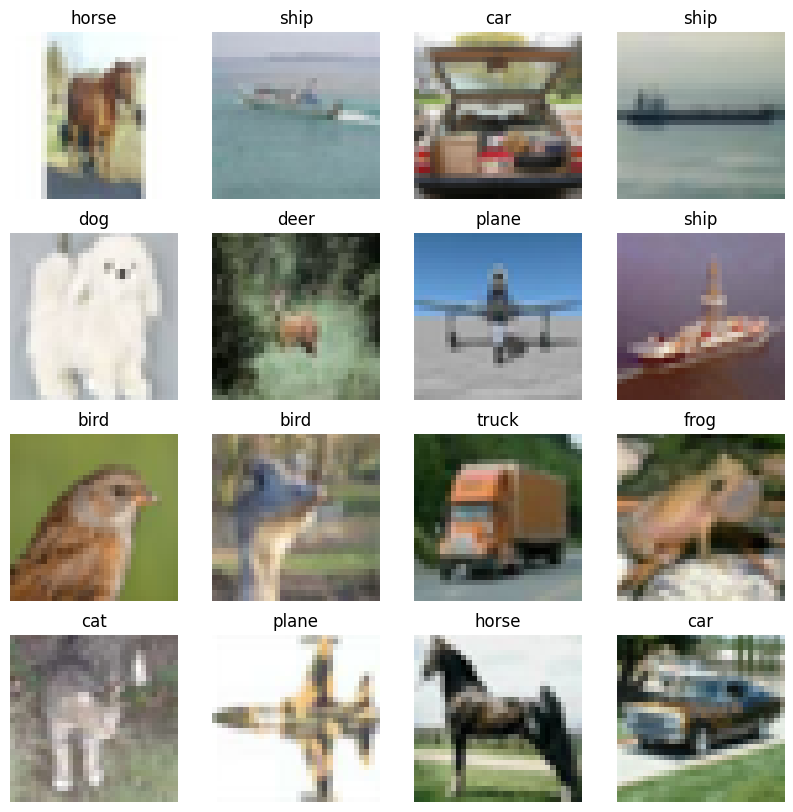

In [ ]:
show(images, labels)

## defina seu modelo aqui

utilize `n.Sequential` para criar o modelo passando como argumento uma lista de camadas.

Obs: utilize `nn.Conv2d(<in_channels>, <out_channels>, <kernel_size>)`, `nn.MaxPool2d(<kernel_size>, <stride>)`, `nn.Linear(<dimensão de entrada>, <dimensão de saída>)` como camada linear
escolha uma função de ativação

## treinamento do modelo

Se baseie no pseudocódigo:

```python
receba modelo, X, y, n_epochs, learning_rate

cria otimizador

para cada epoca em n_epochs:
    zere qualquer gradiente anterior

    para cada batch:
        calcula a saída do modelo para o batch
        
        calcula o custo
        
        propaga o custo para trás
        
        aplica um passo de otmização
```

In [ ]:
# @markdown <h1> Código treinamento </h1>

def train(model, train_loader, optimizer, n_epochs=4, learning_rate=0.005):
    """
        model(x):
            chama o modelo na entrada x

        nn.functional.cross_entropy(y_predito, y_verdadeiro):
             calcula a entropia cruzada entre predição e ground true
             returna [loss]

        loss.backward():
            propaga os gradientes (backpropagation)

        torch.optim.SGD(model.parameters(), learning_rate):
            [otimizador] gradiente descendente estocástico,
            responsavel por atualizar os pesos daado que os gradientes
            já foram calculados

        torch.optim.AdamW(model.parameters(), learning_rate):
            [otimizador] avançado Adam.
            responsavel por atualizar os pesos daado que os gradientes
            já foram calculados

        [otimizador].zero_grad():
             limpa cálculos anteriores

        [otimizador].step()
            atualiza pesos do modelo dado que os gradientes já foram calculados

    """
    calculate_loss = nn.CrossEntropyLoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    for epoch in tqdm(range(n_epochs)):
        epoch_loss = 0
        for x_batch, y_batch in tqdm(train_loader):
            optimizer.zero_grad()

            y_pred = model(x_batch.to(device))

            loss = calculate_loss(y_pred, y_batch.to(device))
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()


        print(f"Epoch {epoch: 06d}: loss: {epoch_loss / len(train_loader): .2f}")


In [ ]:
# @markdown <h1>Creating and training model dor MNIST</h1>

hidden_size = 300  # @param {type:"integer"}
n_layers = 40  # @param {type:"integer"}
kernel_size = 79 # @param {type:"integer"}
pooling_size =  60 # @param {type:"integer"}
pooling_class = "MaxPool2d"   # @param ["MaxPool2d", "AvgPool2d"] {allow-input: true}
first_n_filters = 40  # @param {type:"integer"}
activation_function = 'ReLU' # @param ["ReLU", "LeakyReLU", "GELU", "Sigmoid", "Tanh"] {allow-input: true}
optimizer_name = "SGD"   # @param ["SGD", "RMSprop", "ASGD", "Adam", "Adamax", "Adadelta", "AdamW"] {allow-input: true}

activation_layer = getattr(nn, activation_function)
optimizer = getattr(torch.optim, optimizer_name)
polling =  getattr(nn, pooling_class)

def conv_block(n):
    input_shape = IMAGE_CHANNELS if n == 0 else n * first_n_filters
    return [
        nn.Conv2d(input_shape, (n+1)*first_n_filters, kernel_size=kernel_size),
        activation_layer(),
        polling(pooling_size, pooling_size)
    ]

final_size = (32 - kernel_size + 1) // 2
for n in range(n_layers - 1):
    final_size = (final_size - kernel_size + 1) // 2


model = nn.Sequential(
    *[
        layer
        for n in range(n_layers)
        for layer in conv_block(n)
    ],
    nn.Flatten(),
    nn.Linear(n_layers*first_n_filters*final_size**2, hidden_size),
    activation_layer(),
    nn.Linear(hidden_size, NUM_CLASSES)
).to(device)

print(final_size)
print(model)

n_epochs = 1000 # @param {type:"integer"}
learning_rate = 0.404  # @param {type:"slider", min: 0.0, max:1.0, step: 0.001}

train(model, train_loader, optimizer, n_epochs, learning_rate)

## avaliação

In [ ]:
def predict(model, x):
    with torch.no_grad():
        y_pred = model(x.to(device)).argmax(axis=-1)

    return y_pred.cpu().numpy()

x_test, y_test = zip(*test_dataset)
y_pred = predict(model, torch.stack(x_test))

print(f"A Acurácia do modelo no conjunto que ele não viu foi de "
      f"{100 * accuracy_score(y_test, y_pred): .2f}")

NameError: name 'test_dataset' is not defined

In [ ]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
display.plot()

plt.show()

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
y_pred = predict(model, images)

labels = [f"{CLASSES[label]}, pred: {CLASSES[pred]}" for label, pred in zip(labels, y_pred)]
show(images, labels)